# Hybrid Ensemble for AI Image Detection

High-level hybrid model using four trained backbones:

- EfficientNetV2-S
- ResNet-50
- ViT-B/16
- Xception Net

This notebook performs late-fusion ensemble inference. It loads one model at a time, saves validation/test probabilities, tunes ensemble weights on a balanced validation slice, and evaluates the weighted hybrid on the official CIFAKE test split. Class mapping is normalized as `fake=0`, `real=1`.

In [1]:
# Imports and setup
import os
import sys
import json
import shutil
import zipfile
import subprocess
import gc
from pathlib import Path
from itertools import product

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from torchvision.models import EfficientNet_V2_S_Weights, ResNet50_Weights, ViT_B_16_Weights

try:
    import timm
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "timm"])
    import timm

try:
    from google.colab import drive, files
    IN_COLAB = True
except ModuleNotFoundError:
    drive = None
    files = None
    IN_COLAB = False

seed = 42
rng = np.random.default_rng(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin_memory = device.type == "cuda"
use_amp = device.type == "cuda"
print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


.\.venv-tuned\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU


In [2]:
# Project paths
if IN_COLAB:
    drive.mount('/content/drive', force_remount=False)
    DEFAULT_PROJECT_ROOT = Path('/content/drive/MyDrive/TDK_AI_Detection')
else:
    DEFAULT_PROJECT_ROOT = Path.cwd()

PROJECT_ROOT = Path(os.getenv('TDK_PROJECT_ROOT', DEFAULT_PROJECT_ROOT)).expanduser().resolve()
MODEL_DIR = PROJECT_ROOT / 'models'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
HYBRID_DIR = OUTPUT_DIR / 'hybrid'
CACHE_DIR = HYBRID_DIR / 'probability_cache'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
HYBRID_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Set this to True if you want to force fresh model inference instead of reusing cached probabilities.
FORCE_RECOMPUTE_CACHE = False
CACHE_FORMAT_VERSION = 2

print('Running in Colab:', IN_COLAB)
print('Project root:', PROJECT_ROOT)
print('Model dir:', MODEL_DIR)
print('Hybrid output dir:', HYBRID_DIR)


Running in Colab: False
Project root: .
Model dir: .\models
Hybrid output dir: .\outputs\hybrid


In [3]:
# Kaggle credentials and CIFAKE download/extract
KAGGLE_DIR = Path('/root/.kaggle') if IN_COLAB else Path(os.getenv('KAGGLE_CONFIG_DIR', Path.home() / '.kaggle'))
KAGGLE_JSON = KAGGLE_DIR / 'kaggle.json'
LOCAL_KAGGLE_JSON_CANDIDATES = [PROJECT_ROOT / 'kaggle.json', Path.cwd() / 'kaggle.json']

if not KAGGLE_JSON.exists():
    local_kaggle_json = next((path for path in LOCAL_KAGGLE_JSON_CANDIDATES if path.exists()), None)
    if local_kaggle_json is not None:
        KAGGLE_DIR.mkdir(parents=True, exist_ok=True)
        shutil.copy2(local_kaggle_json, KAGGLE_JSON)
        try:
            os.chmod(KAGGLE_JSON, 0o600)
        except OSError:
            pass
        print('Copied Kaggle credentials to:', KAGGLE_JSON)

if not KAGGLE_JSON.exists() and IN_COLAB:
    print('Upload kaggle.json now, or set KAGGLE_USERNAME and KAGGLE_KEY as environment variables.')
    uploaded = files.upload()
    if 'kaggle.json' in uploaded:
        KAGGLE_DIR.mkdir(parents=True, exist_ok=True)
        KAGGLE_JSON.write_bytes(uploaded['kaggle.json'])
        os.chmod(KAGGLE_JSON, 0o600)

HAS_KAGGLE_CREDENTIALS = KAGGLE_JSON.exists() or bool(os.getenv('KAGGLE_USERNAME') and os.getenv('KAGGLE_KEY'))


def get_kaggle_command():
    candidates = []
    kaggle_exe = shutil.which('kaggle')
    if kaggle_exe:
        candidates.append(Path(kaggle_exe))

    exe_dir = Path(sys.executable).resolve().parent
    if os.name == 'nt':
        candidates.extend([
            exe_dir / 'kaggle.exe',
            exe_dir / 'Scripts' / 'kaggle.exe',
            Path(sys.prefix) / 'Scripts' / 'kaggle.exe',
            Path.home() / 'AppData' / 'Roaming' / 'Python' / 'Scripts' / 'kaggle.exe',
        ])
    else:
        candidates.extend([
            exe_dir / 'kaggle',
            exe_dir.parent / 'bin' / 'kaggle',
            Path(sys.prefix) / 'bin' / 'kaggle',
            Path.home() / '.local' / 'bin' / 'kaggle',
        ])

    for candidate in candidates:
        if candidate and candidate.exists():
            return [str(candidate)]

    print('Kaggle CLI not found. Installing kaggle package...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'kaggle'], check=True)

    for candidate in candidates:
        if candidate and candidate.exists():
            return [str(candidate)]

    kaggle_exe = shutil.which('kaggle')
    if kaggle_exe:
        return [kaggle_exe]

    raise FileNotFoundError(
        'Kaggle package installed, but kaggle executable was not found. '
        'Restart the kernel or add your Python Scripts folder to PATH.'
    )

DATASET_SLUG = 'birdy654/cifake-real-and-ai-generated-synthetic-images'
ZIP_NAME = 'cifake-real-and-ai-generated-synthetic-images.zip'
ZIP_PATH = Path(os.getenv('CIFAKE_ZIP', (Path('/content') if IN_COLAB else PROJECT_ROOT) / ZIP_NAME)).expanduser().resolve()
EXTRACT_ROOT = Path(os.getenv('CIFAKE_ROOT', Path('/content/CIFAKE_FULL') if IN_COLAB else PROJECT_ROOT / 'CIFAKE_FULL')).expanduser().resolve()


def split_exists(root, split_name):
    root = Path(root)
    split_name = split_name.lower()
    return any(path.is_dir() and path.name.lower() == split_name for path in root.rglob('*')) if root.exists() else False

needs_extract = not (split_exists(EXTRACT_ROOT, 'train') and split_exists(EXTRACT_ROOT, 'test'))
if needs_extract and not ZIP_PATH.exists():
    if not HAS_KAGGLE_CREDENTIALS:
        raise FileNotFoundError('Missing kaggle.json. Put it next to this notebook, put it in ~/.kaggle/, or set KAGGLE_USERNAME and KAGGLE_KEY.')
    print('Downloading official full CIFAKE dataset from Kaggle...')
    ZIP_PATH.parent.mkdir(parents=True, exist_ok=True)
    subprocess.check_call(get_kaggle_command() + ['datasets', 'download', '-d', DATASET_SLUG, '-p', str(ZIP_PATH.parent)])

if needs_extract:
    print('Unzipping CIFAKE into:', EXTRACT_ROOT)
    EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_file:
        zip_file.extractall(EXTRACT_ROOT)
else:
    print('CIFAKE_FULL already exists and has train/test folders.')


CIFAKE_FULL already exists and has train/test folders.


In [4]:
# Locate dataset folders and verify official counts
def find_split_folder(root, split_name):
    split_name = split_name.lower()
    for current_root, dirs, _ in os.walk(root):
        for dirname in dirs:
            if dirname.lower() == split_name:
                return Path(current_root) / dirname
    raise FileNotFoundError(f"Could not find {split_name!r} folder under {root}")

def find_class_folder(split_dir, class_name):
    class_name = class_name.lower()
    for child in Path(split_dir).iterdir():
        if child.is_dir() and child.name.lower() == class_name:
            return child
    raise FileNotFoundError(f"Could not find class folder {class_name!r} under {split_dir}")

def count_images(folder):
    valid_exts = tuple(datasets.folder.IMG_EXTENSIONS)
    return sum(1 for path in Path(folder).rglob("*") if path.is_file() and path.suffix.lower() in valid_exts)

train_dir = find_split_folder(EXTRACT_ROOT, "train")
test_dir = find_split_folder(EXTRACT_ROOT, "test")

train_fake_count = count_images(find_class_folder(train_dir, "fake"))
train_real_count = count_images(find_class_folder(train_dir, "real"))
test_fake_count = count_images(find_class_folder(test_dir, "fake"))
test_real_count = count_images(find_class_folder(test_dir, "real"))

print("Train fake:", train_fake_count)
print("Train real:", train_real_count)
print("Test fake:", test_fake_count)
print("Test real:", test_real_count)

if train_fake_count != 50000 or train_real_count != 50000:
    raise ValueError("Training split does not match official CIFAKE counts: 50,000 fake + 50,000 real.")
if test_fake_count != 10000 or test_real_count != 10000:
    raise ValueError("Test split does not match official CIFAKE counts: 10,000 fake + 10,000 real.")


Train fake: 50000
Train real: 50000
Test fake: 10000
Test real: 10000


In [5]:
# Model checkpoint paths
MODEL_SPECS = {
    "efficientnetv2s": {
        "path": MODEL_DIR / "efficientnetv2s_final.pth",
        "image_size": 224,
    },
    "resnet50": {
        "path": MODEL_DIR / "resnet50_best_10epochs.pth",
        "image_size": 224,
    },
    "vit_b16": {
        "path": MODEL_DIR / "vit_b16_final_official.pth",
        "image_size": 224,
    },
    "xception": {
        "path": MODEL_DIR / "xception_final_official.pth",
        "image_size": 299,
    },
}

missing = [name for name, spec in MODEL_SPECS.items() if not spec["path"].exists()]
if missing:
    print("Missing model weights:")
    for name in missing:
        print(" -", name, "expected at", MODEL_SPECS[name]["path"])
    raise FileNotFoundError("Train/copy all four model weights before running the Hybrid notebook.")

for name, spec in MODEL_SPECS.items():
    print(name, "->", spec["path"])


efficientnetv2s -> .\models\efficientnetv2s_final.pth
resnet50 -> .\models\resnet50_best_10epochs.pth
vit_b16 -> .\models\vit_b16_final_official.pth
xception -> .\models\xception_final_official.pth


In [6]:
# Dataset helpers
normalize_mean = [0.485, 0.456, 0.406]
normalize_std = [0.229, 0.224, 0.225]
class_names = ["fake", "real"]

batch_size = 16
num_workers = int(os.getenv("LOCAL_NUM_WORKERS", "0"))  # 0 is safest on Windows/Jupyter.
validation_per_class = int(os.getenv("HYBRID_VALIDATION_PER_CLASS", "2000"))  # tune ensemble weights on 4,000 train images total by default.


def make_transforms(image_size):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=normalize_mean, std=normalize_std),
    ])


def make_dataset(split_dir, image_size):
    raw = datasets.ImageFolder(split_dir, transform=make_transforms(image_size))
    fake_original_idx = next(idx for name, idx in raw.class_to_idx.items() if name.lower() == "fake")
    real_original_idx = next(idx for name, idx in raw.class_to_idx.items() if name.lower() == "real")

    def remap_target(target):
        if target == fake_original_idx:
            return 0
        if target == real_original_idx:
            return 1
        raise ValueError(f"Unexpected target index: {target}")

    ds = datasets.ImageFolder(split_dir, transform=make_transforms(image_size), target_transform=remap_target)
    original_to_normalized = {fake_original_idx: 0, real_original_idx: 1}
    normalized_targets = np.array([original_to_normalized[target] for _, target in raw.samples])
    return ds, normalized_targets


def balanced_indices(normalized_targets, per_class):
    selected = []
    for label in [0, 1]:
        label_indices = np.where(normalized_targets == label)[0]
        if len(label_indices) < per_class:
            raise ValueError(f"Class {label} only has {len(label_indices)} samples, requested {per_class}.")
        selected.extend(rng.choice(label_indices, size=per_class, replace=False).tolist())
    rng.shuffle(selected)
    return selected


# Use the same validation image indices for every model.
_, train_targets_for_selection = make_dataset(train_dir, 224)
VAL_INDICES = balanced_indices(train_targets_for_selection, validation_per_class)
print("Validation samples selected:", len(VAL_INDICES))


Validation samples selected: 4000


In [7]:
# Model builders
def build_efficientnetv2s():
    model = models.efficientnet_v2_s(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, 2)
    return model


def build_resnet50():
    model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model


def build_vit_b16():
    model = models.vit_b_16(weights=None)
    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, 2)
    return model


def build_xception():
    return timm.create_model("legacy_xception", pretrained=False, num_classes=2)

MODEL_BUILDERS = {
    "efficientnetv2s": build_efficientnetv2s,
    "resnet50": build_resnet50,
    "vit_b16": build_vit_b16,
    "xception": build_xception,
}


In [8]:
# Sequential probability inference and caching
@torch.no_grad()
def predict_probabilities(model_name, split_name):
    spec = MODEL_SPECS[model_name]
    checkpoint_stat = spec["path"].stat()
    cache_path = CACHE_DIR / f"{model_name}_{split_name}_probs.npz"
    if cache_path.exists() and FORCE_RECOMPUTE_CACHE:
        cache_path.unlink()
        print(f"Deleted old cache because FORCE_RECOMPUTE_CACHE=True: {cache_path}", flush=True)

    if cache_path.exists():
        with np.load(cache_path, allow_pickle=False) as cached:
            probs = cached["probs"]
            targets = cached["targets"]
            cache_valid = (
                int(cached.get("cache_format_version", -1)) == CACHE_FORMAT_VERSION
                and int(cached.get("checkpoint_size", -1)) == checkpoint_stat.st_size
                and int(cached.get("checkpoint_mtime_ns", -1)) == checkpoint_stat.st_mtime_ns
                and probs.ndim == 2
                and probs.shape[1] == 2
                and len(probs) == len(targets)
                and np.isfinite(probs).all()
            )
        if cache_valid:
            print(
                f"Loaded validated probabilities: {cache_path} | "
                f"probs={probs.shape}, targets={targets.shape}",
                flush=True,
            )
            return probs, targets
        print(f"Ignoring stale or invalid probability cache: {cache_path}", flush=True)

    image_size = spec["image_size"]
    if split_name == "val":
        dataset, _ = make_dataset(train_dir, image_size)
        dataset = Subset(dataset, VAL_INDICES)
    elif split_name == "test":
        dataset, _ = make_dataset(test_dir, image_size)
    else:
        raise ValueError(f"Unknown split: {split_name}")

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory, persistent_workers=num_workers > 0)

    model = MODEL_BUILDERS[model_name]()
    state = torch.load(spec["path"], map_location="cpu", weights_only=True)
    model.load_state_dict(state)
    model = model.to(device)
    model.eval()

    probs_batches = []
    target_batches = []
    for images, targets in tqdm(loader, desc=f"{model_name} {split_name}"):
        images = images.to(device, non_blocking=True)
        # Full float32 inference avoids rare EfficientNet softmax NaNs seen under AMP.
        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        probs_batches.append(probs.detach().cpu().numpy())
        target_batches.append(targets.numpy())

    probs = np.concatenate(probs_batches, axis=0)
    targets = np.concatenate(target_batches, axis=0)
    if not np.isfinite(probs).all():
        raise FloatingPointError(f"Non-finite probabilities produced for {model_name} {split_name}")
    np.savez_compressed(
        cache_path,
        probs=probs,
        targets=targets,
        cache_format_version=np.array(CACHE_FORMAT_VERSION, dtype=np.int64),
        checkpoint_size=np.array(checkpoint_stat.st_size, dtype=np.int64),
        checkpoint_mtime_ns=np.array(checkpoint_stat.st_mtime_ns, dtype=np.int64),
    )
    print(
        f"Saved cached probabilities: {cache_path} | "
        f"probs={probs.shape}, targets={targets.shape}",
        flush=True,
    )

    del model
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()

    return probs, targets

val_probs = {}
test_probs = {}
y_val = None
y_test = None

for model_name in MODEL_SPECS:
    print(f"\nRunning hybrid inference for: {model_name}", flush=True)
    val_probs[model_name], model_y_val = predict_probabilities(model_name, "val")
    test_probs[model_name], model_y_test = predict_probabilities(model_name, "test")

    if y_val is None:
        y_val = model_y_val
    elif not np.array_equal(y_val, model_y_val):
        raise ValueError(f"Validation target order mismatch for {model_name}")

    if y_test is None:
        y_test = model_y_test
    elif not np.array_equal(y_test, model_y_test):
        raise ValueError(f"Test target order mismatch for {model_name}")

print("Validation samples:", len(y_val))
print("Test samples:", len(y_test))



Running hybrid inference for: efficientnetv2s


Loaded validated probabilities: .\outputs\hybrid\probability_cache\efficientnetv2s_val_probs.npz | probs=(4000, 2), targets=(4000,)


Loaded validated probabilities: .\outputs\hybrid\probability_cache\efficientnetv2s_test_probs.npz | probs=(20000, 2), targets=(20000,)



Running hybrid inference for: resnet50


Loaded validated probabilities: .\outputs\hybrid\probability_cache\resnet50_val_probs.npz | probs=(4000, 2), targets=(4000,)


...

xception test: 100%|█████████▉| 1248/1250 [01:02<00:00, 19.80it/s]

xception test: 100%|██████████| 1250/1250 [01:03<00:00, 19.83it/s]

xception test: 100%|██████████| 1250/1250 [01:03<00:00, 19.82it/s]

Saved cached probabilities: .\outputs\hybrid\probability_cache\xception_test_probs.npz | probs=(20000, 2), targets=(20000,)


Validation samples: 4000
Test samples: 20000


In [9]:
# Individual model performance
individual_results = {}
for model_name in MODEL_SPECS:
    val_pred = val_probs[model_name].argmax(axis=1)
    test_pred = test_probs[model_name].argmax(axis=1)
    individual_results[model_name] = {
        "val_accuracy": float(accuracy_score(y_val, val_pred)),
        "test_accuracy": float(accuracy_score(y_test, test_pred)),
        "test_precision_fake_positive": float(precision_score(y_test, test_pred, pos_label=0, zero_division=0)),
        "test_recall_fake_positive": float(recall_score(y_test, test_pred, pos_label=0, zero_division=0)),
        "test_f1_fake_positive": float(f1_score(y_test, test_pred, pos_label=0, zero_division=0)),
    }
    print(model_name, individual_results[model_name])


efficientnetv2s {'val_accuracy': 0.76025, 'test_accuracy': 0.75665, 'test_precision_fake_positive': 0.6976511359260685, 'test_recall_fake_positive': 0.9059, 'test_f1_fake_positive': 0.7882532086143137}
resnet50 {'val_accuracy': 0.9955, 'test_accuracy': 0.98125, 'test_precision_fake_positive': 0.9821661156196774, 'test_recall_fake_positive': 0.9803, 'test_f1_fake_positive': 0.9812321705620339}
vit_b16 {'val_accuracy': 0.968, 'test_accuracy': 0.95945, 'test_precision_fake_positive': 0.9441275978733688, 'test_recall_fake_positive': 0.9767, 'test_f1_fake_positive': 0.9601376259523224}
xception {'val_accuracy': 0.98575, 'test_accuracy': 0.9775, 'test_precision_fake_positive': 0.9755028878709421, 'test_recall_fake_positive': 0.9796, 'test_f1_fake_positive': 0.9775471509829359}


In [10]:
# Tune weighted soft-voting ensemble on validation split
model_names = list(MODEL_SPECS.keys())
val_stack = np.stack([val_probs[name] for name in model_names], axis=0)
test_stack = np.stack([test_probs[name] for name in model_names], axis=0)

candidate_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
best_weights = None
best_val_acc = -1.0

for raw_weights in product(candidate_values, repeat=len(model_names)):
    total = sum(raw_weights)
    if total <= 0:
        continue
    weights = np.array(raw_weights, dtype=np.float64) / total
    blended = np.tensordot(weights, val_stack, axes=(0, 0))
    preds = blended.argmax(axis=1)
    acc = accuracy_score(y_val, preds)
    if acc > best_val_acc:
        best_val_acc = acc
        best_weights = weights

print("Best validation accuracy:", best_val_acc)
print("Best ensemble weights:")
for name, weight in zip(model_names, best_weights):
    print(f"  {name}: {weight:.3f}")


Best validation accuracy: 0.998
Best ensemble weights:
  efficientnetv2s: 0.091
  resnet50: 0.455
  vit_b16: 0.000
  xception: 0.455


In [11]:
# Evaluate final Hybrid on official test split
test_hybrid_probs = np.tensordot(best_weights, test_stack, axes=(0, 0))
y_pred = test_hybrid_probs.argmax(axis=1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
recall = recall_score(y_test, y_pred, pos_label=0, zero_division=0)
f1 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

print("Hybrid Test Results")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}  (fake as positive)")
print(f"Recall:    {recall:.4f}  (fake as positive)")
print(f"F1-score:  {f1:.4f}  (fake as positive)")
print()
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))


Hybrid Test Results
Accuracy:  0.9857
Precision: 0.9839  (fake as positive)
Recall:    0.9875  (fake as positive)
F1-score:  0.9857  (fake as positive)

              precision    recall  f1-score   support

        fake       0.98      0.99      0.99     10000
        real       0.99      0.98      0.99     10000

    accuracy                           0.99     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       0.99      0.99      0.99     20000



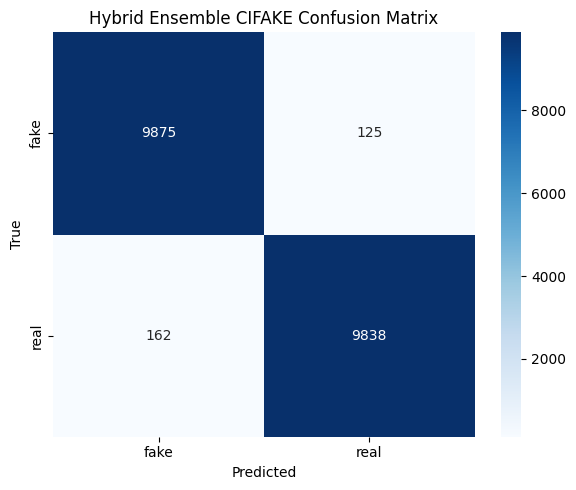

Saved confusion matrix to: .\outputs\hybrid\hybrid_confusion_matrix_official.png


In [12]:
# Confusion matrix
CONFUSION_MATRIX_PATH = HYBRID_DIR / "hybrid_confusion_matrix_official.png"

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Hybrid Ensemble CIFAKE Confusion Matrix")
plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_PATH, dpi=300)
plt.show()

print("Saved confusion matrix to:", CONFUSION_MATRIX_PATH)


In [13]:
# Save Hybrid metrics and predictions
METRICS_PATH = HYBRID_DIR / "hybrid_final_metrics_official.json"
PREDICTIONS_PATH = HYBRID_DIR / "hybrid_test_predictions_official.npz"

results = {
    "model": "weighted soft-voting hybrid ensemble",
    "members": model_names,
    "class_mapping": {"fake": 0, "real": 1},
    "dataset": "official full CIFAKE",
    "validation_samples": int(len(y_val)),
    "test_samples": int(len(y_test)),
    "inference_config": {"batch_size": batch_size},
    "weights": {name: float(weight) for name, weight in zip(model_names, best_weights)},
    "validation_accuracy_for_selected_weights": float(best_val_acc),
    "individual_model_results": individual_results,
    "hybrid_test_metrics": {
        "accuracy": float(accuracy),
        "precision_fake_positive": float(precision),
        "recall_fake_positive": float(recall),
        "f1_fake_positive": float(f1),
        "confusion_matrix": cm.tolist(),
    },
    "saved_files": {
        "metrics_json": str(METRICS_PATH),
        "test_predictions_npz": str(PREDICTIONS_PATH),
        "confusion_matrix": str(CONFUSION_MATRIX_PATH),
        "probability_cache_dir": str(CACHE_DIR),
    },
}

with open(METRICS_PATH, "w") as f:
    json.dump(results, f, indent=4)

np.savez_compressed(
    PREDICTIONS_PATH,
    y_true=y_test,
    y_pred=y_pred,
    hybrid_probs=test_hybrid_probs,
    model_names=np.array(model_names),
    weights=best_weights,
)

print("Saved Hybrid metrics to:", METRICS_PATH)
print("Saved Hybrid predictions to:", PREDICTIONS_PATH)
print("\nHybrid run complete.")
print("Selected weights:")
print(json.dumps(results["weights"], indent=4))
print("\nHybrid test metrics:")
print(json.dumps(results["hybrid_test_metrics"], indent=4))


Saved Hybrid metrics to: .\outputs\hybrid\hybrid_final_metrics_official.json
Saved Hybrid predictions to: .\outputs\hybrid\hybrid_test_predictions_official.npz

Hybrid run complete.
Selected weights:
{
    "efficientnetv2s": 0.09090909090909091,
    "resnet50": 0.45454545454545453,
    "vit_b16": 0.0,
    "xception": 0.45454545454545453
}

Hybrid test metrics:
{
    "accuracy": 0.98565,
    "precision_fake_positive": 0.9838597190395536,
    "recall_fake_positive": 0.9875,
    "f1_fake_positive": 0.985676498477816,
    "confusion_matrix": [
        [
            9875,
            125
        ],
        [
            162,
            9838
        ]
    ]
}


In [14]:
# Inspect saved Hybrid metrics
with open(METRICS_PATH, "r") as f:
    saved_metrics = json.load(f)

print("Saved metrics file:", METRICS_PATH)
print("Weights:")
print(json.dumps(saved_metrics["weights"], indent=4))
print("Hybrid test metrics:")
print(json.dumps(saved_metrics["hybrid_test_metrics"], indent=4))


Saved metrics file: .\outputs\hybrid\hybrid_final_metrics_official.json
Weights:
{
    "efficientnetv2s": 0.09090909090909091,
    "resnet50": 0.45454545454545453,
    "vit_b16": 0.0,
    "xception": 0.45454545454545453
}
Hybrid test metrics:
{
    "accuracy": 0.98565,
    "precision_fake_positive": 0.9838597190395536,
    "recall_fake_positive": 0.9875,
    "f1_fake_positive": 0.985676498477816,
    "confusion_matrix": [
        [
            9875,
            125
        ],
        [
            162,
            9838
        ]
    ]
}


### Article Summary: Hybrid Ensemble for AI-Generated Image Detection

#### 1. Project Overview & Objective

- Task: Combine multiple trained image classifiers to improve fake-vs-real CIFAKE detection.
- Ensemble method: Weighted soft-voting over model probabilities.
- Member models: efficientnetv2s, resnet50, vit_b16, xception.
- Dataset: Official CIFAKE dataset from Kaggle.

#### 2. Validation and Test Setup

- Ensemble weight selection: 4,000 validation images from the training split, balanced as 2,000 fake and 2,000 real.
- Final test set: 20,000 images from the full CIFAKE test split, balanced as 10,000 fake and 10,000 real.
- Batch size for inference: 16.
- The validation subset is used only for choosing ensemble weights; final metrics are reported on the separate full test set.

#### 3. Selected Ensemble Weights

- EfficientNetV2-S: 0.0909
- ResNet50: 0.4545
- ViT-B/16: 0.0000
- Xception: 0.4545
- Validation accuracy for selected weights: 0.9978

#### 4. Individual Model Test Accuracy

- EfficientNetV2-S: 0.7575
- ResNet50: 0.9812
- ViT-B/16: 0.9595
- Xception: 0.9776

#### 5. Final Hybrid Evaluation Metrics (Test Set)

The hybrid ensemble was evaluated on the full 20,000-image CIFAKE test set:

- Overall accuracy: 0.9855
- Precision, fake positive: 0.9836
- Recall, fake positive: 0.9875
- F1-score, fake positive: 0.9855
- Test loss: not computed for the hybrid ensemble; final evaluation is based on soft-voting probabilities and classification metrics.

#### 6. Confusion Matrix Insights

- Fake identified as fake: 9,875 / 10,000
- Fake identified as real: 125
- Real identified as fake: 165
- Real identified as real: 9,835 / 10,000

#### Key Takeaway

The weighted hybrid ensemble achieved 98.55% accuracy on the full CIFAKE test set, outperforming the individual member models in this run. The selected weighting emphasized ResNet50 and Xception, gave a smaller contribution to EfficientNetV2-S, and assigned ViT-B/16 zero weight for the best validation score in the tested weight grid.
